## Validación cruzada dentro del grid search

La validación cruzada (o *cross-validation*) es una técnica utilizada para evaluar la capacidad de un modelo para generalizar a datos no vistos. Dentro de un procedimiento como el *GridSearchCV*, la validación cruzada se combina con la búsqueda de hiperparámetros para encontrar los valores que optimicen el rendimiento del modelo en un conjunto de validación. A continuación te lo explico de manera ilustrativa:

### Paso 1: División de los datos
El conjunto de datos se divide en varias particiones o "folds". Por ejemplo, si utilizamos 5-fold *cross-validation*:
- Se divide el conjunto de datos en 5 partes de aproximadamente el mismo tamaño.
- En cada iteración, una de las partes se utiliza como conjunto de validación y las otras 4 partes como conjunto de entrenamiento.

El objetivo es que cada partición actúe como conjunto de validación una vez, de modo que se pueda evaluar el modelo en todas las particiones.

### Paso 2: Uso en *GridSearchCV*
Dentro de *GridSearchCV*, esta técnica se usa para probar diferentes combinaciones de hiperparámetros en cada uno de los pliegues de validación cruzada, y se calcula un promedio del rendimiento. El modelo que obtiene el mejor promedio de desempeño es seleccionado como el mejor modelo.

Voy a ilustrarlo con código y visualizaciones sencillas para que quede claro.

### Ejemplo en Python

#### 1. Importar librerías y generar datos simples

Comenzamos generando un conjunto de datos y preparando una búsqueda en grilla con validación cruzada.


In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:

### Generar un conjunto de datos sintético simple
X, y = make_classification(n_samples=100, n_features=10, random_state=42)

In [3]:
### Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Crear un modelo básico de regresión logística
model = LogisticRegression(max_iter=1000)


#### 2. Visualizar los folds de la validación cruzada

Podemos simular visualmente el proceso de validación cruzada.


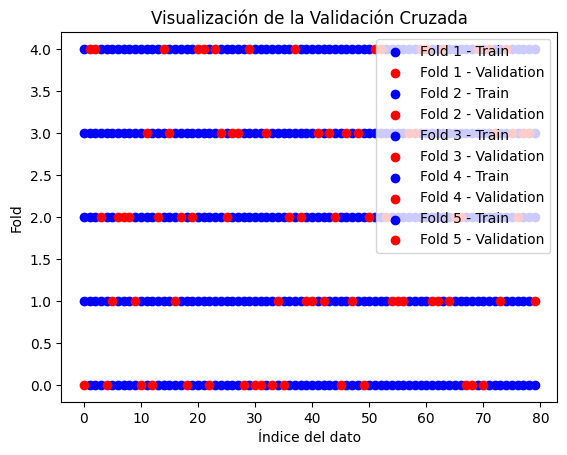

In [5]:
# Definir una validación cruzada con 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Visualizar los folds
folds = []
for train_index, val_index in kf.split(X_train):
    folds.append((train_index, val_index))

# Visualizamos los índices de los datos utilizados para entrenamiento y validación en cada fold
fig, ax = plt.subplots()
for i, (train_index, val_index) in enumerate(folds):
    ax.scatter(train_index, [i]*len(train_index), label=f'Fold {i+1} - Train', color='blue')
    ax.scatter(val_index, [i]*len(val_index), label=f'Fold {i+1} - Validation', color='red')
ax.set_xlabel("Índice del dato")
ax.set_ylabel("Fold")
plt.legend(loc='best')
plt.title("Visualización de la Validación Cruzada")
plt.show()

In [6]:
# Hiperparámetros a probar
param_grid = [0.01, 0.1, 1, 10, 100]

# Almacenar los resultados de cada combinación de hiperparámetros y de cada pliegue
results = {}

# Entrenamiento manual en cada pliegue
for C in param_grid:
    accuracies = []
    for train_index, val_index in kf.split(X):
        # Dividimos los datos
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        # Creamos el modelo con el hiperparámetro actual
        model = LogisticRegression(C=C, max_iter=1000)

        # Entrenar el modelo
        model.fit(X_train, y_train)

        # Predecir en el conjunto de validación
        y_pred = model.predict(X_val)

        # Calcular la exactitud en el conjunto de validación
        acc = accuracy_score(y_val, y_pred)
        accuracies.append(acc)

    # Almacenar el promedio de accuracy para cada valor de C
    results[C] = accuracies

In [7]:
# Crear un DataFrame para ver mejor los resultados
df_results = pd.DataFrame(results)

# Agregar una fila con el promedio de cada columna (hiperparámetro C)
df_results.loc['Promedio'] = df_results.mean()

print(df_results)

          0.01    0.10    1.00    10.00   100.00
0           1.00    1.00    1.00    1.00    1.00
1           0.85    0.95    0.90    0.90    0.90
2           0.95    0.90    0.95    0.95    0.95
3           0.95    0.95    1.00    1.00    1.00
4           1.00    1.00    0.95    0.95    0.95
Promedio    0.95    0.96    0.96    0.96    0.96


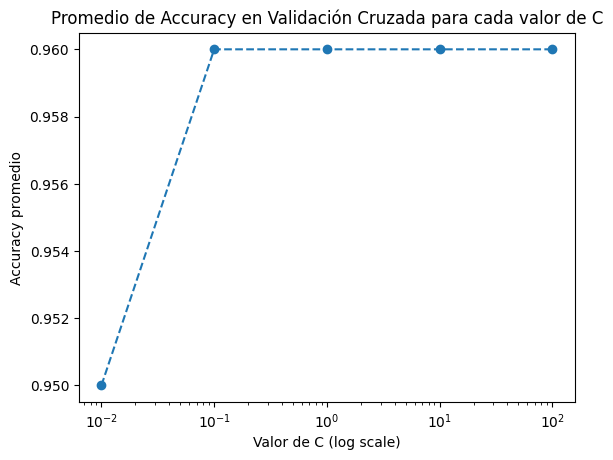

In [8]:
# Graficar los resultados promedio para cada valor de C
plt.plot(param_grid, df_results.loc['Promedio'], marker='o', linestyle='--')
plt.xscale('log')
plt.xlabel('Valor de C (log scale)')
plt.ylabel('Accuracy promedio')
plt.title('Promedio de Accuracy en Validación Cruzada para cada valor de C')
plt.show()



#### 3. Usar *GridSearchCV* con validación cruzada

Ahora utilizaremos *GridSearchCV* para buscar el mejor hiperparámetro en un modelo de regresión logística simple.


In [ ]:
from sklearn.model_selection import GridSearchCV

# Definir hiperparámetros a buscar
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

# Definir el GridSearchCV con validación cruzada de 5 folds
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')

# Ajustar el modelo con validación cruzada
grid_search.fit(X_train, y_train)

# Mostrar el mejor hiperparámetro encontrado
print(f"Mejor hiperparámetro: {grid_search.best_params_}")
print(f"Mejor accuracy promedio: {grid_search.best_score_:.4f}")

Mejor hiperparámetro: {'C': 10}
Mejor accuracy promedio: 0.9625



#### 4. Explicación de los resultados

En cada uno de los 5 pliegues (folds) de la validación cruzada, *GridSearchCV* ajusta el modelo utilizando cuatro partes para entrenamiento y una parte para validación. Calcula la métrica (en este caso *accuracy*) y repite el proceso para todas las combinaciones de hiperparámetros.

Finalmente, promedia las métricas de los 5 pliegues para cada combinación de hiperparámetros y elige la combinación que obtiene el mejor resultado promedio.



#### 5. Visualización de los resultados de los pliegues

Podemos visualizar los resultados de cada pliegue para cada valor de hiperparámetro \(C\).


In [ ]:
# Obtener resultados de validación cruzada
results = pd.DataFrame(grid_search.cv_results_)

# Visualizamos el accuracy para cada valor de C en los 5 folds
plt.figure(figsize=(8,6))
for i in range(5):
    plt.plot(param_grid['C'], results[f'split{i}_test_score'], label=f'Fold {i+1}')

plt.plot(param_grid['C'], results['mean_test_score'], label='Promedio', color='black', linewidth=2)
plt.xscale('log')
plt.xlabel('Valor de C')
plt.ylabel('Accuracy')
plt.title('Resultados de Validación Cruzada por Fold')
plt.legend(loc='best')
plt.show()


#### 6. Interpretación del gráfico

En el gráfico, puedes ver cómo varía el *accuracy* en cada fold para los diferentes valores de \(C\). La línea negra representa el promedio del rendimiento en los 5 pliegues para cada valor de \(C\). El modelo con el valor de \(C\) que tiene el mejor promedio es seleccionado como el mejor modelo.

